# **zkAuction**

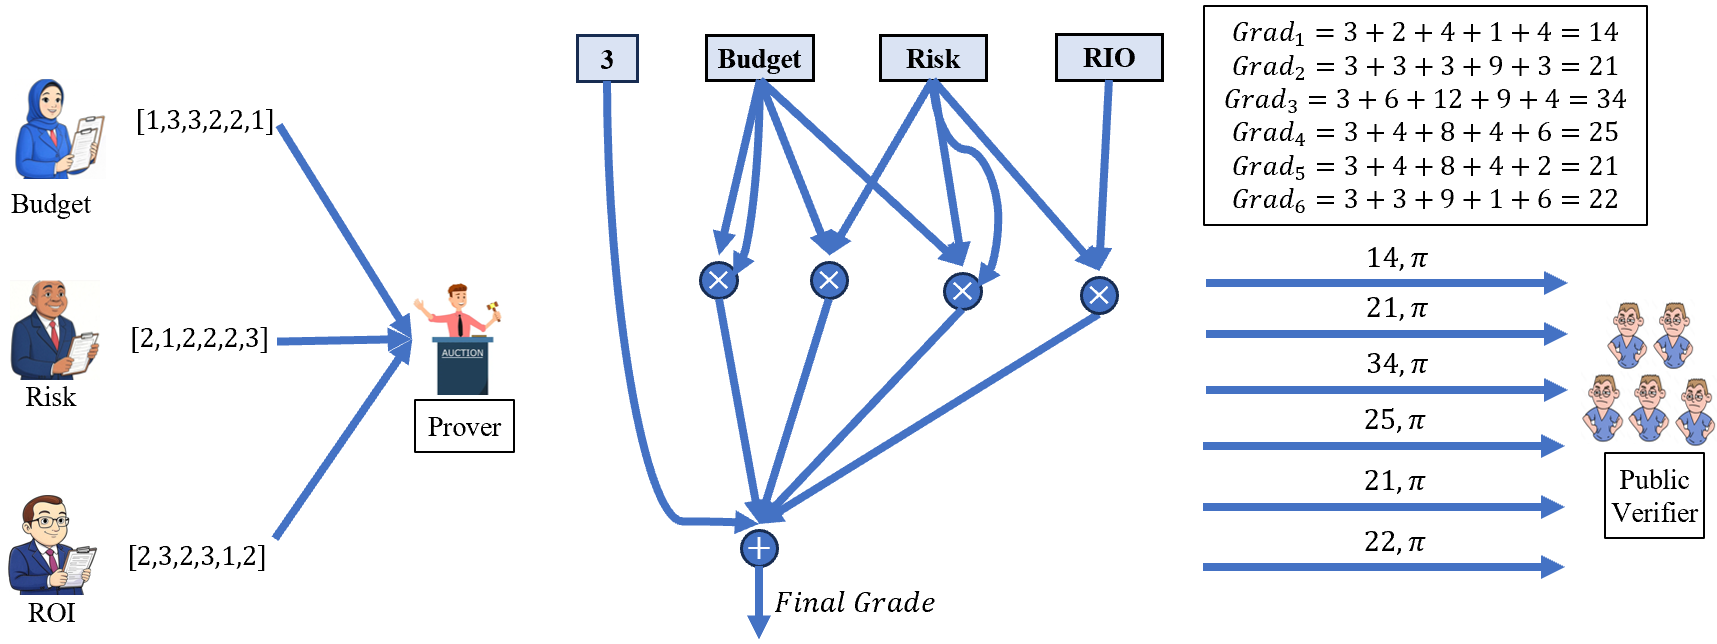

# **py_ecc is a Python implementation of elliptic curve cryptography, including support for various curves like BN128, secp256k1, and bls12_381.**

In [1]:
!pip install py-ecc
!pip install galois

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 95.9 MB/s eta 0:00:00


# **Circuit Definition**

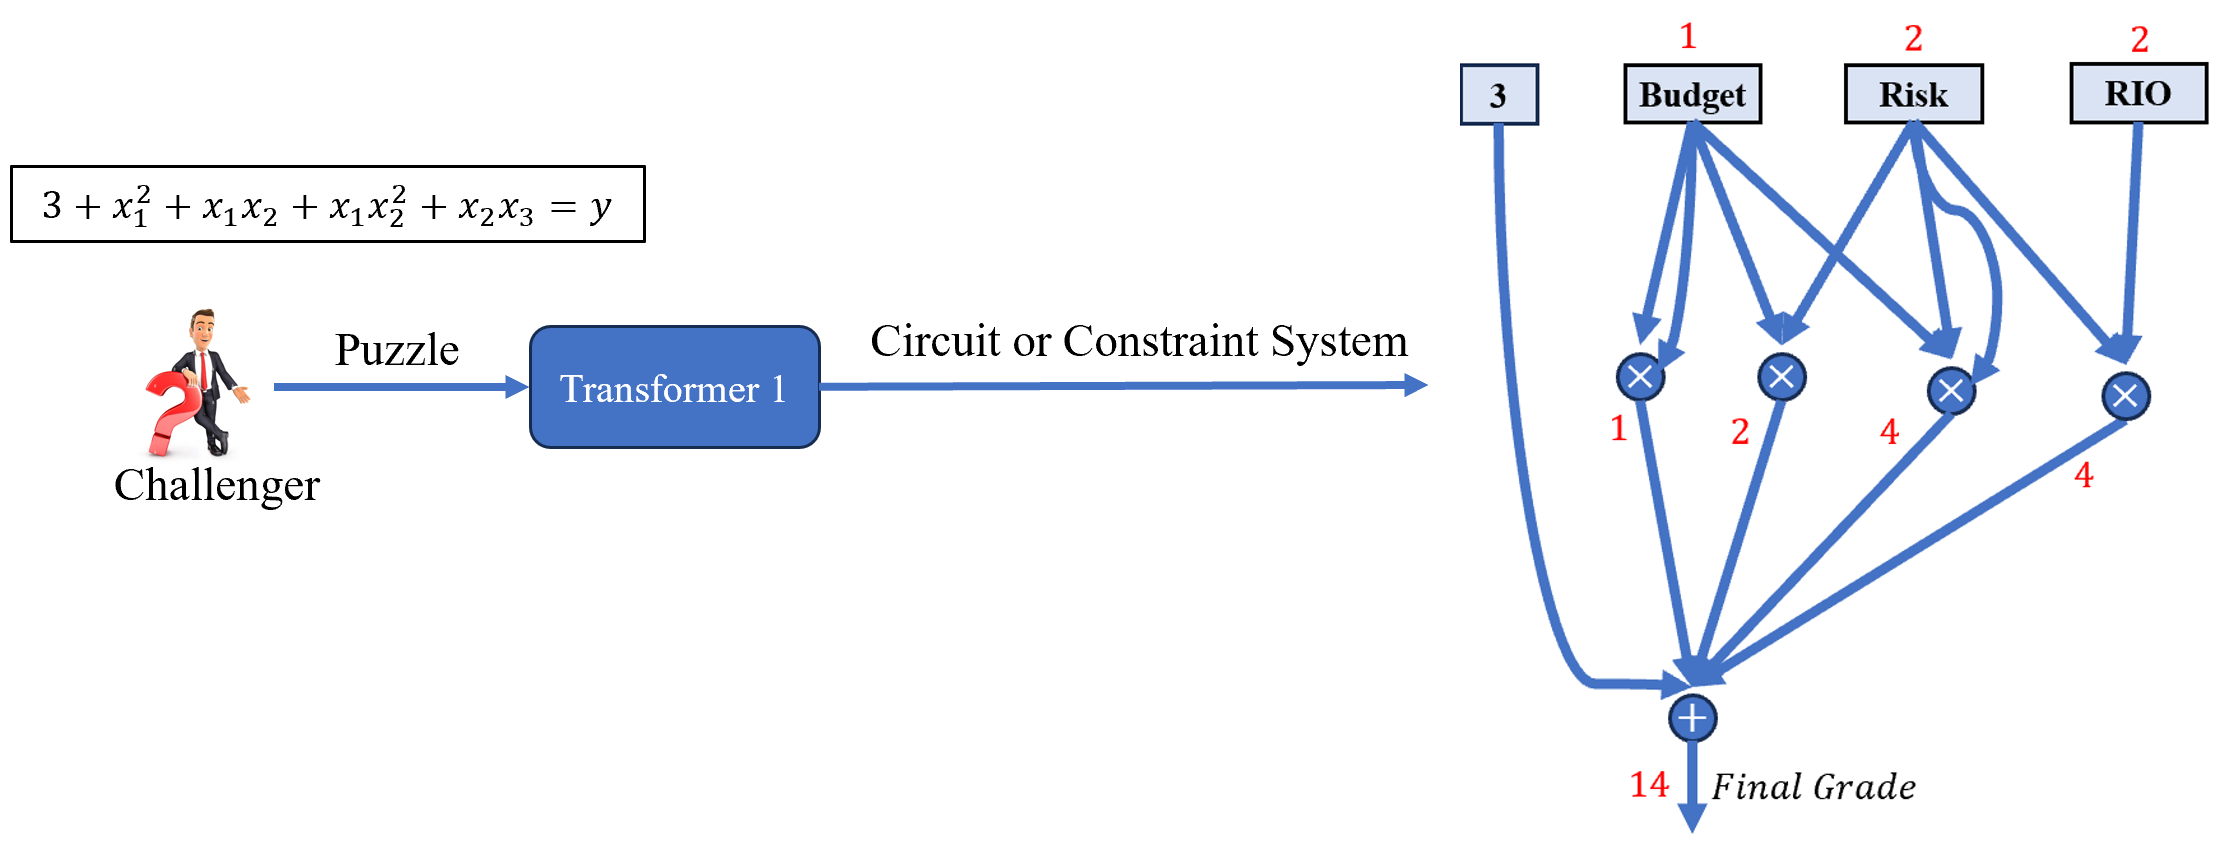

In [2]:
import galois
import numpy as np

#p = 101
p = 21888242871839275222246405745257275088548364400416034343698204186575808495617
FP = galois.GF(p)

x1 = FP(1)
x2 = FP(2)
x3 = FP(2)

v1 = x1 * x1
v2 = x1 * x2
v3 = x2 * v2
y = x2 * x3 + v1 + v2 + v3 + FP(3)

# **Converting Constraint Systems into Matrises**

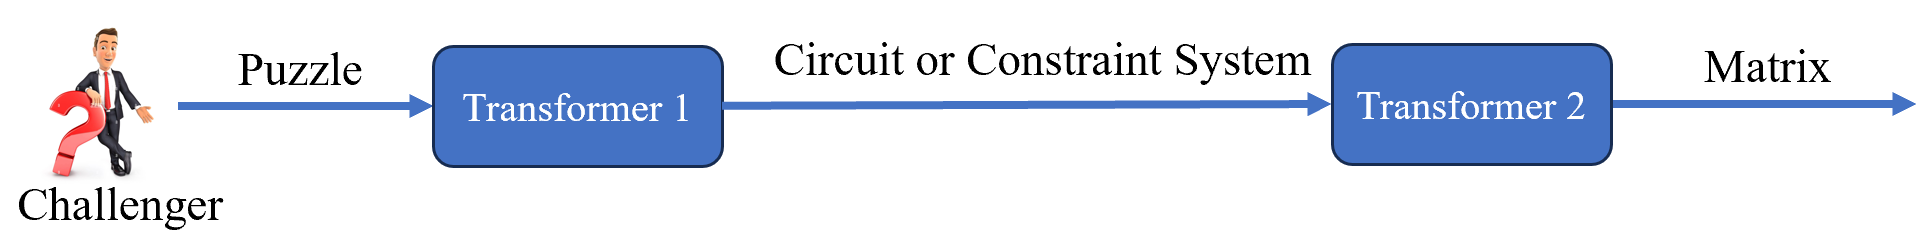

In [3]:
xL = FP([[0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0]])

xR = FP([[0, 0, 1, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 1, 0, 0, 0]])

xO = FP([[0, 0, 0, 0, 0, 1, 0, 0],
         [0, 0, 0, 0, 0, 0, 1, 0],
         [0, 0, 0, 0, 0, 0, 0, 1],
         [FP(p - 3), 1, 0, 0, 0, FP(p - 1), FP(p - 1), FP(p - 1)]])

# **Naive Protocol**

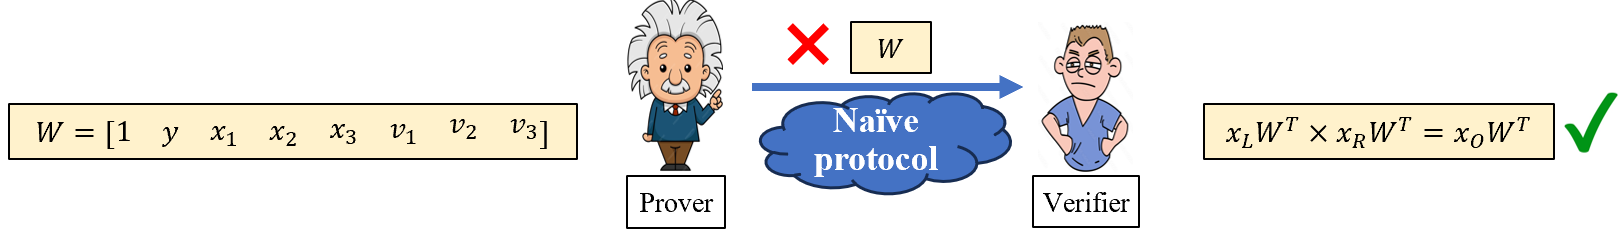

In [4]:
W = FP([1, y, x1, x2, x3, v1, v2, v3])
print("W =", W)

xLWT = np.dot(xL, W)
xRWT = np.dot(xR, W)
xOWT = np.dot(xO, W)

print("xL.WT =", xLWT)
print("xR.WT =", xRWT)

xLWTxRWT = np.multiply(xLWT, xRWT)

print("xL.WT * xR.WT =", xLWTxRWT)

print("xO.WT =", xOWT)

assert np.all(xLWTxRWT == xOWT)
print("\nxLWT * xRWT = xOWT! So, verification is passed!")

W = [ 1 14  1  2  2  1  2  4]
xL.WT = [1 1 2 2]
xR.WT = [1 2 2 2]
xL.WT * xR.WT = [1 2 4 4]
xO.WT = [1 2 4 4]

xLWT * xRWT = xOWT! So, verification is passed!


# **QAP (convering matrises into polynomials)**

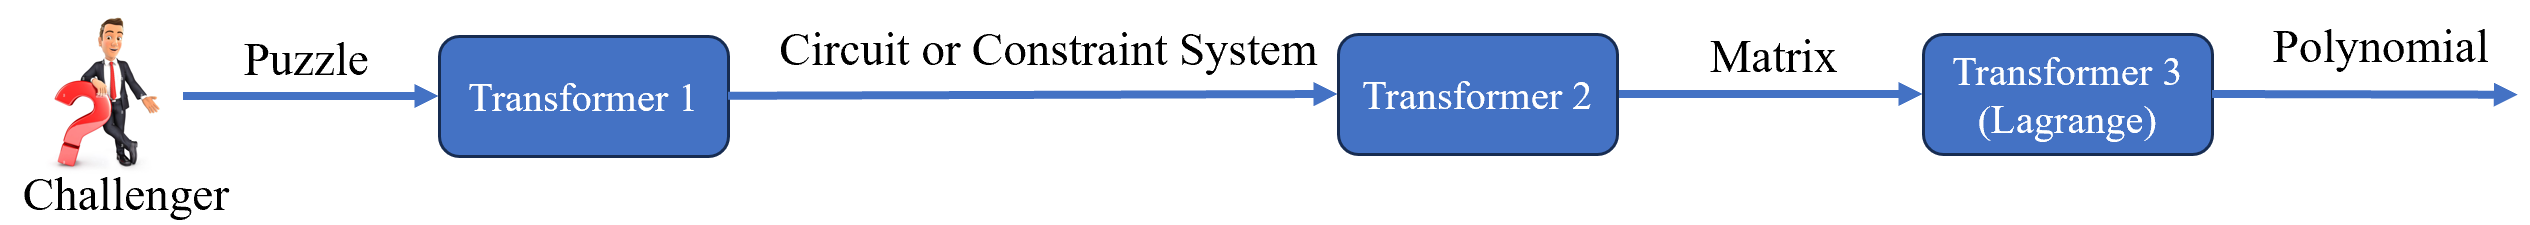

In [5]:
mtxs = [xL, xR, xO]
poly_m = []

for m in mtxs:
    poly_list = []
    for i in range(0, m.shape[1]):
        points_x = FP(np.zeros(m.shape[0], dtype=int))
        points_y = FP(np.zeros(m.shape[0], dtype=int))
        for j in range(0, m.shape[0]):
            points_x[j] = FP(j+1)
            points_y[j] = m[j][i]

        poly = galois.lagrange_poly(points_x, points_y)
        coef = poly.coefficients()[::-1]
        if len(coef) < m.shape[0]:
            coef = np.append(coef, np.zeros(m.shape[0] - len(coef), dtype=int))
        poly_list.append(coef)

    poly_m.append(FP(poly_list))

L_polys = poly_m[0]
R_polys = poly_m[1]
O_polys = poly_m[2]

print(f'''L_polys
{L_polys}
''')

print(f'''R_polys
{R_polys}
''')

print(f'''O_polys
{O_polys}
''')

Lx = galois.Poly((W @ L_polys)[::-1])
Rx = galois.Poly((W @ R_polys)[::-1])
Ox = galois.Poly((W @ O_polys)[::-1])

print("L(x) = ", Lx)
print("R(x) = ", Rx)
print("O(x) = ", Ox)

L_polys
[[                                                                            0
                                                                              0
                                                                              0
                                                                              0]
 [                                                                            0
                                                                              0
                                                                              0
                                                                              0]
 [21888242871839275222246405745257275088548364400416034343698204186575808495615
  18240202393199396018538671454381062573790303667013361953081836822146507079686
  10944121435919637611123202872628637544274182200208017171849102093287904247806
  14592161914559516814830937163504850059032242933610689562465469457717205663745]
 [                           

# **Computing Polynomials T(x) and H(x)**

In [ ]:
Tx = galois.Poly([1, p-1], field=FP)
for i in range(2, xL.shape[0] + 1):
    Tx *= galois.Poly([1, p-i], field=FP)

print("\nT(x) = ", Tx)
for i in range(1, xL.shape[0] + 2):
    #print(f"T({i}) = ", Tx(i))
    if i == xL.shape[0]:
        print("-"*10)

Hx = (Lx * Rx - Ox) // Tx
rem = (Lx * Rx - Ox) % Tx

print("H(x) = ", Hx)
print("rem(x) = ", rem)

assert rem == 0


T(x) =  x^4 + 21888242871839275222246405745257275088548364400416034343698204186575808495607x^3 + 35x^2 + 21888242871839275222246405745257275088548364400416034343698204186575808495567x + 24
----------
H(x) =  1216013492879959734569244763625404171586020244467557463538789121476433805312x^2 + 13984155168119536947546314781692147973239232811376910830696074896978988761089x + 10944121435919637611123202872628637544274182200208017171849102093287904247808
rem(x) =  0


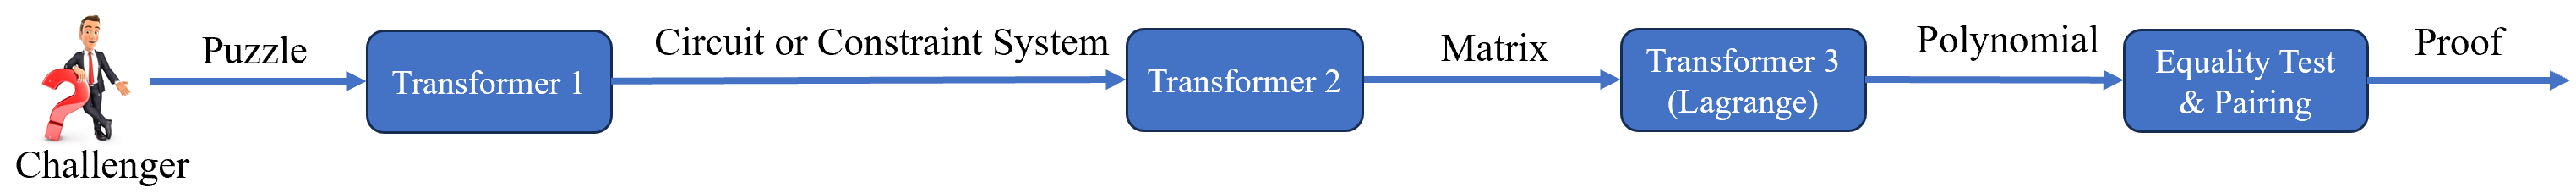

# **Test version 1**

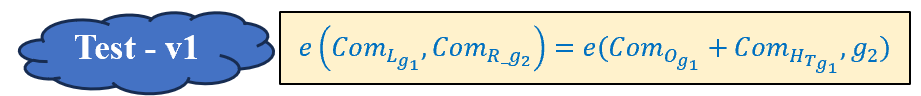

# **Test 1 - Generating Public Parameters (SRS) by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)

tau = FP(20)
print(f"The trusted authority chooses that toxic waste: τ = {tau}")

Lx_tau = Lx(tau)
Rx_tau = Rx(tau)
Ox_tau = Ox(tau)

Tx_tau = Tx(tau)
# print(f"\nT(τ) = {Tx_tau}")

Hx_tau = Hx(tau)

HTx_tau = Hx_tau*Tx_tau

assert Lx_tau * Rx_tau == Ox_tau + HTx_tau, f"{Lx_tau} * {Rx_tau} - {Ox_tau} != {HTx_tau}"
print("This equation is correct: Lx(τ)*Rx(τ) = Ox(τ) + HTx(τ)")

from py_ecc.optimized_bn128 import multiply, G1, G2, add, pairing, neg, normalize

SRS_G1 = [multiply(G1, int(tau**i)) for i in range(0, Tx.degree)]                        # G1[τ^0], G1[τ^1], ..., G1[τ^d]
SRS_G2 = [multiply(G2, int(tau**i)) for i in range(0, Tx.degree)]                        # G2[τ^0], G2[τ^1], ..., G2[τ^d-1]
SRS_Ttau_G1 = [multiply(G1, int(tau**i * Tx_tau)) for i in range(0, Tx.degree - 1)]      # G1[τ^0 * T(τ)], G1[τ^1 * T(τ)], ..., G1[τ^d-1 * T(τ)]

print("SRS Generation:")
print("-"*10)
print(f"SRS_G1 = {[normalize(point) for point in SRS_G1]}")
print(f"\nSRS_G2 = {[normalize(point) for point in SRS_G2]}")
print(f"\nSRS_Ttau_G1 = {[normalize(point) for point in SRS_Ttau_G1]}")

Setup phase
----------
The trusted authority chooses that toxic waste: τ = 20
This equation is correct: Lx(τ)*Rx(τ) = Ox(τ) + HTx(τ)
SRS Generation:
----------
SRS_G1 = [(1, 2), (18947110137775984544896515092961257947872750783784269176923414004072777296602, 12292085037693291586083644966434670280746730626861846747147579999202931064992), (16262199471205794413544947826745938654132104752637586692048329713311590397011, 13296900385261935021718889695689394625708483652039722230815936262285054528714), (21603600070689675766438470661345954782419355034652174505468210225883925863279, 15787091953565760722773063158476721787069408761080596737736006929439659337677)]

SRS_G2 = [((10857046999023057135944570762232829481370756359578518086990519993285655852781, 11559732032986387107991004021392285783925812861821192530917403151452391805634), (8495653923123431417604973247489272438418190587263600148770280649306958101930, 4082367875863433681332203403145435568316851327593401208105741076214120093531)), ((658445688

# **Test 1 - Gerating Proof by Prover**

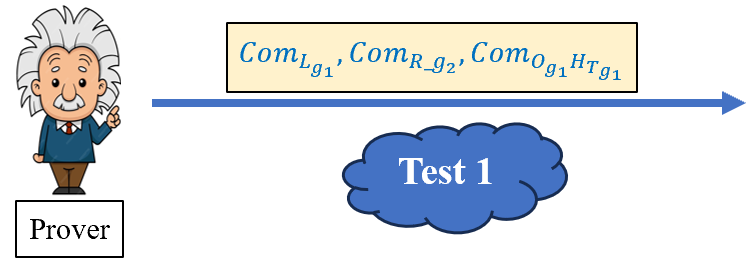

In [ ]:
def compute_commit(poly, trusted_points, verbose=False):
    coeff = poly.coefficients()[::-1]

    assert len(coeff) == len(trusted_points), "Polynomial degree mismatch!"

    if verbose:
        [print(normalize(point)) for point in trusted_points]

    terms = [multiply(point, int(coeff)) for point, coeff in zip(trusted_points, coeff)]
    evaluation = terms[0]
    for i in range(1, len(terms)):
        evaluation = add(evaluation, terms[i])

    if verbose:
        print("-"*10)
        print(normalize(evaluation))
    return evaluation

print("\nProof generation by the prover:")
print("-"*10)

Com_L_G1 = compute_commit(Lx, SRS_G1)         # G1[L0 * τ^0] + G1[L1 * τ^1] + ... + G1[Ld-1 * τ^d-1]
Com_R_G2 = compute_commit(Rx, SRS_G2)         # G2[R0 * τ^0] + G2[R1 * τ^1] + ... + G2[Rd-1 * τ^d-1]
Com_O_G1 = compute_commit(Ox, SRS_G1)         # G1[O0 * τ^0] + G1[O1 * τ^1] + ... + G1[Od-1 * τ^d-1]
Com_H_TG1 = compute_commit(Hx, SRS_Ttau_G1)   # G1[h0 * τ^0 * T(τ)] + G1[h1 * τ^1 * T(τ)] + ... + G1[hd-2 * τ^d-2 * T(τ)]
Com_O_G1_H_TG1 = add(Com_O_G1, Com_H_TG1)

print(f"Com_L_G1 = {normalize(Com_L_G1)}")
print(f"Com_R_G2 = {normalize(Com_R_G2)}")
print(f"Com_O_G1 = {normalize(Com_O_G1)}")
print(f"Com_H_TG1 = {normalize(Com_H_TG1)}")
print(f"Com_O_G1_H_TG1 = {normalize(Com_O_G1_H_TG1)}")


Proof generation by the prover:
----------
Com_L_G1 = (8330299257207133901366871257155253971314607279354149606073562533406110264547, 13345463579135942203737952219627406471933418676587554145102648257331589450917)
Com_R_G2 = ((14326906891250287543549585272926111143695335746080311111181382675518085820718, 6387665317811506075353696070342206918183252367638706775880553426817420740190), (17803917450656089866628003288899838192598386205936110059528807174490106620001, 13244691466842852733820157569436468888494230088864367280620854176532490227812))
Com_O_G1 = (978385795310540113980752194047158536662943315706746702446792802570722742179, 10942266149083412598752721851596515918369934085070908890383381252612351799252)
Com_H_TG1 = (19752002169675664742016440163386686712136799917955423913877142241088310714027, 2263523974808433351463726298965648561856070748721266874070583808013131033143)
Com_O_G1_H_TG1 = (6781797482772617544093789422659523444119823845771524015193876451343524055271, 4671386325261193868319

# **Test 1 - Verifying Proof by Verifier**

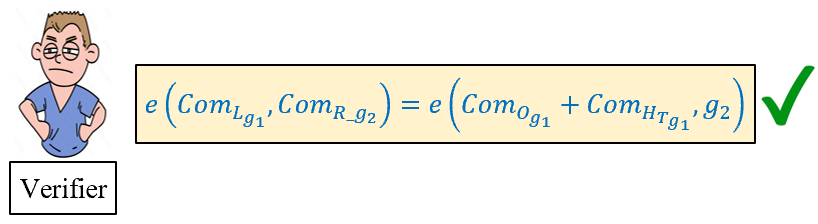

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_R_G2,Com_L_G1) = {pairing(Com_R_G2,Com_L_G1)}")
print(f"pairing(G2,add(Com_O_G1, Com_H_TG1)) = {pairing(G2,Com_O_G1_H_TG1)}")

assert pairing(Com_R_G2,Com_L_G1) == pairing(G2,Com_O_G1_H_TG1)    # e(Com_L_G1, Com_R_G2) == e(Com_OHT_G1, G2[1])
print("Pairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_R_G2,Com_L_G1) = (20044869322806486341256116912696678966272861900367812024833022084902582721402, 14617782383245721254957367643160636140365409032337695391660268740986564314427, 14010518429498122339133663493966543300697058620869580398049457611513326243326, 5104624772323373030883067573851187360262780833750727557719735967301460970301, 14951319909466716212542704711894054281189272488140306185234098468526798019120, 18870037177077598050290540247939770717228150470562413380590328010954317447592, 13627470939014200125255294358830052931944723702869870551669082235592528237016, 14744044471415109854596244919960006487218383226303549535124415210018071427309, 14514891577615921788423663441961582427043881932901740059385008567772921026657, 9855201620735676646405334759666048286547693128080712838828106223568715360399, 695279323358635920513436935393242761720793713972030637909627878857038261370, 197424621139283578987603905422729475645911983246315497728

# **Test 2 - Checking**

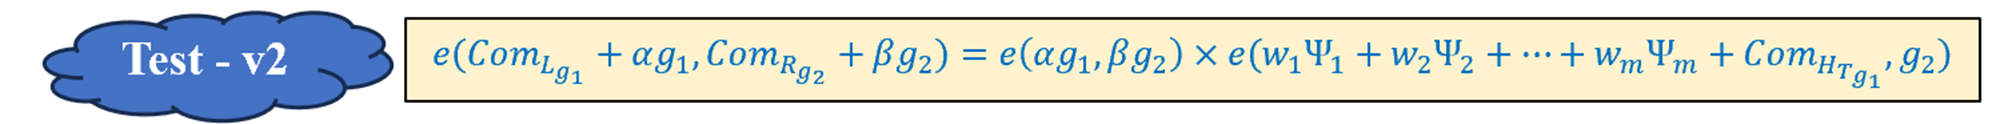

# **Test 2 - Choosing α, β by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)
print("Toxic waste:")
tau = FP(20)
alpha = FP(2)
beta = FP(3)

print(f"τ = {tau}")
print(f"α = {alpha}")
print(f"β = {beta}")

Setup phase
----------
Toxic waste:
τ = 20
α = 2
β = 3


# **Test 2 - Computing psi by trusted authority**

In [ ]:
def evaluate_poly_list(poly_list, x):
    results = []
    for poly in poly_list:
        results.append(poly(x))
    return results

def print_evaluation(name, results):
    print(f'\n{name} polynomial evaluations:')
    for i in range(0, len(results)):
        print(f'{name}_{i} = {results[i]}')

def to_poly(mtx):
    poly_list = []
    for i in range(0, mtx.shape[0]):
        poly_list.append( galois.Poly(mtx[i][::-1]) )
    return poly_list

def print_poly(name, poly_list):
    print(f'\n{name} polynomials:')
    for i in range(0, len(poly_list)):
        print(f'{name}_{i} = {poly_list[i]}')

beta_L = beta * L_polys
alpha_R = alpha * R_polys

print("βL\n", beta_L)
print("αR\n", alpha_R)
print("O\n", O_polys)

psi = beta_L + alpha_R + O_polys
print("psi = βL + αR + O\n", psi)

psi_p = to_poly(psi)
print_poly("psi", psi_p)

print("psi evaluations:")
psi_eval = evaluate_poly_list(psi_p, tau)
print([int(k) for k in psi_eval])




βL
 [[                                                                            0
                                                                              0
                                                                              0
                                                                              0]
 [                                                                            0
                                                                              0
                                                                              0
                                                                              0]
 [21888242871839275222246405745257275088548364400416034343698204186575808495611
  10944121435919637611123202872628637544274182200208017171849102093287904247824
  10944121435919637611123202872628637544274182200208017171849102093287904247801
                                                                              1]
 [                               

# **Test 2 - Generating SRS**

In [ ]:
from py_ecc.optimized_bn128 import multiply, G1, G2, add, pairing, neg, normalize, eq

alphaG1 = multiply(G1, int(alpha))         # G1[α]
betaG2 = multiply(G2, int(beta))    # G2[α]
psi_G1 = [multiply(G1, int(k)) for k in psi_eval]       # G1[βU0(τ) + αV0(τ) + W0(τ)], G1[βU1(τ) + αV1(τ) + W1(τ)], ..., G1[βUd(τ) + αVd(τ) + Wd(τ)]

print("Trusted setup:")
print("-"*10)
print(f"\n[α]G1 = {normalize(alphaG1)}")
print(f"[β]G2 = {normalize(betaG2)}")
print(f"psi_G1 = {[normalize(point) for point in psi_G1]}")

Trusted setup:
----------

[α]G1 = (1368015179489954701390400359078579693043519447331113978918064868415326638035, 9918110051302171585080402603319702774565515993150576347155970296011118125764)
[β]G2 = ((2725019753478801796453339367788033689375851816420509565303521482350756874229, 7273165102799931111715871471550377909735733521218303035754523677688038059653), (2512659008974376214222774206987427162027254181373325676825515531566330959255, 957874124722006818841961785324909313781880061366718538693995380805373202866))
psi_G1 = [(15109545746291084922552306312511119954309054765462096921966046290415470591210, 13242302596027169293957385862470134814369991004809892313328051693777586305563), (1540147615742092855122362390273215696202300989980535937807544369063691019287, 916302540883947080468652904864832717784863855769927076757632797189693955321), (18804211169039775038933336545642735227175996909885142997881990426375176668393, 18105711799171793856875962475376067119098034682906361994944309019534398278526

# **Test 2 - Proof genration by Prover**

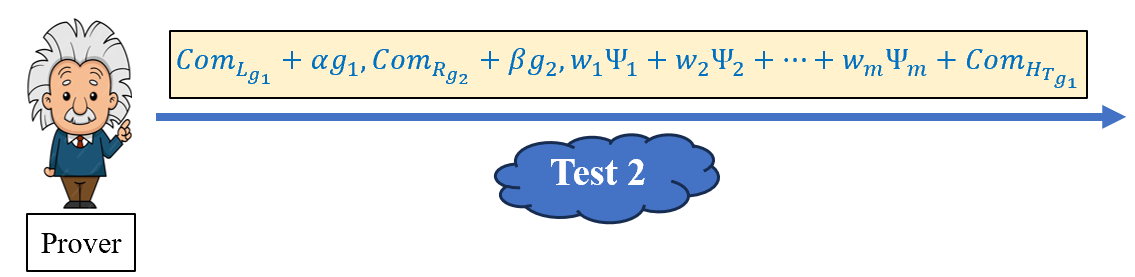

In [ ]:
print("\nProof generation:")
print("-"*10)

Com_Lalpha_G1 = add(Com_L_G1, alphaG1)        # G1[A] = G1[A] + G1[α]
Com_Rbeta_G2 = add(Com_R_G2, betaG2)    # G2[B] = G2[B] + G2[β]
# assert len(W) == len(psi_G1), "Polynomial degree mismatch!"    # w0 * G1[k0] + w1 * G1[k1] + ... + wd-1 * G1[kd-1]
psi_G1 = [multiply(G1, int(k)) for k in psi_eval]
psi_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_G1, W)]
sum_psi_G1 = psi_G1_terms[0]
for i in range(1, len(psi_G1_terms)):
    sum_psi_G1 = add(sum_psi_G1, psi_G1_terms[i])
Com_sum_psi_H_TG1 = add(Com_H_TG1, sum_psi_G1)

print(f"Com_Lalpha_G1 = {normalize(Com_Lalpha_G1)}")
print(f"Com_Rbeta_G2 = {normalize(Com_Rbeta_G2)}")
print(f"Com_sum_psi + Com_H_TG1 = {normalize(Com_sum_psi_H_TG1)}")
#print(f"psi_G1 = {normalize(psi_G1)}")


Proof generation:
----------
Com_Lalpha_G1 = (6013509164801733979484825298125890311250008879028105433014821636846005797706, 19488490250007553715211274125059285411216555852832561222655819441866084802945)
Com_Rbeta_G2 = ((14832382623816558293321436949995228330968369232237372980684098426986180048417, 4020460819550067514360699571742745456648476420239400449002304761539601824742), (10529604492022540410806456504830518554972588370519164696186168631874316550960, 2800311358029433188730959120784430150005527245870684085334967838318687685467))
Com_sum_psi + Com_H_TG1 = (1294920821533209802733402785120235237977628261140120283214790407179795045266, 17995860513182203386132757434923669883316913205551626978483692774751147024502)


# **Test 2 - Proof verification by Verifier**

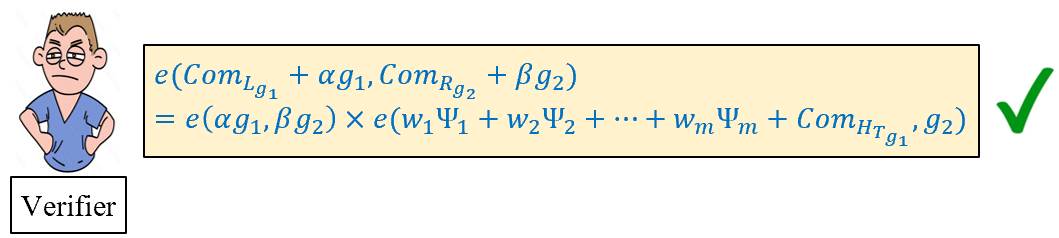

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_Rbeta_G2,Com_Lalpha_G1) = {pairing(Com_Rbeta_G2,Com_Lalpha_G1)}")
print(f"pairing(betaG2, alphaG1) = {pairing(betaG2, alphaG1)}")
print(f"pairing(G2, Com_sum_psi_H_TG1) = {pairing(G2, Com_sum_psi_H_TG1)}")
print(f"pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1) = {pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1)}")

assert pairing(Com_Rbeta_G2,Com_Lalpha_G1) == pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1)
print("\nPairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_Rbeta_G2,Com_Lalpha_G1) = (18315320689072325987318339888686928926441082924835991541797929305789972708511, 561735336946250655241320754693905052090171931275706394757282629272334035561, 2819579540518582154272583612630673578532241960548125342990723245962393408028, 2450270091158035240806490146116205641702304438430768873404257228289211806875, 8964815260025788331687177081606778988951731817758516356792078048327610303278, 13961744504695830217965810288769940327868983596768014116365339942793057408422, 9470708380232385341823467405856530673994539734709634204080349610241613983628, 9957174780837583358956742704006082847457622905482382506439309322934856236724, 11717073097485800213879760857393898747402838011302455220929810970078851993073, 2559690243784152603210391351796569761569785541724961783192939677986218691944, 15080244493518759585967219176070439710786160305064088969126700528314164895952, 1619751403299499069861880822459607081570692866462890

# **Test 3 - Checking**

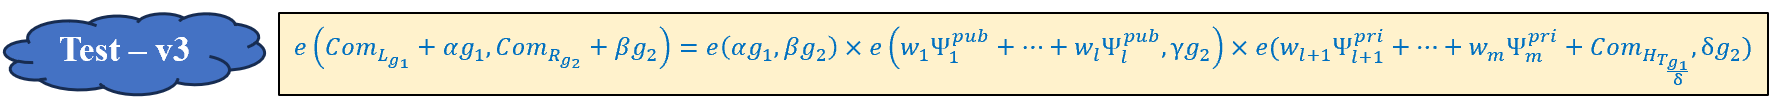

# **Test 3 -Choosing gamma, delta (γ, δ) by trusted authority**

In [ ]:
print("Setup phase")
print("-"*10)
print("Toxic waste:")
tau = FP(20)
alpha = FP(2)
beta = FP(3)
gamma = FP(4)
delta = FP(5)

print(f"τ = {tau}")
print(f"α = {alpha}")
print(f"β = {beta}")
print(f"γ = {gamma}")
print(f"δ = {delta}")

Setup phase
----------
Toxic waste:
τ = 20
α = 2
β = 3
γ = 4
δ = 5


# **Test 3 -Generating SRS by trusted authority**

In [ ]:
print("Trusted setup:")
print("-"*10)

gammaG2 = multiply(G2, int(gamma))
print(f"\ngammaG2 = {normalize(gammaG2)}")

deltaG2 = multiply(G2, int(delta))
print(f"deltaG2 = {normalize(deltaG2)}")

powers_tauTtau_div_delta = [(tau**i * Tx_tau) / delta for i in range(0, Tx.degree - 1)]
SRS_Ttau_div_delta_G1 = [multiply(G1, int(pTd)) for pTd in powers_tauTtau_div_delta]
print(f"(τT(τ)/δ)*G1 = {[normalize(point) for point in SRS_Ttau_div_delta_G1]}")
assert len(SRS_Ttau_div_delta_G1) == len(Hx.coefficients()), f"SRS_Ttau_div_delta_G1 length mismatch! {len(SRS_Ttau_div_delta_G1)} != {len(H.coefficients())}"

W_pub = W[:2]
W_pri = W[2:]

psi_pub_ints= [int(psi_eval[k]) for k in range(2)];
psi_pri_ints=[int(psi_eval[k]) for k in range(2,len(psi_eval))]

psi_pub = [FP(k)/gamma for k in psi_pub_ints]
psi_pri = [FP(k)/delta for k in psi_pri_ints]

psi_pub_G1 = [multiply(G1, int(k)) for k in psi_pub]
psi_pri_G1 = [multiply(G1, int(k)) for k in psi_pri]

print(f"[psi/γ]G1 = {[normalize(point) for point in psi_pub_G1]}")
print(f"[psi/δ]G1 = {[normalize(point) for point in psi_pri_G1]}")

Trusted setup:
----------

gammaG2 = ((18936818173480011669507163011118288089468827259971823710084038754632518263340, 18556147586753789634670778212244811446448229326945855846642767021074501673839), (18825831177813899069786213865729385895767511805925522466244528695074736584695, 13775476761357503446238925910346030822904460488609979964814810757616608848118))
deltaG2 = ((20954117799226682825035885491234530437475518021362091509513177301640194298072, 4540444681147253467785307942530223364530218361853237193970751657229138047649), (21508930868448350162258892668132814424284302804699005394342512102884055673846, 11631839690097995216017572651900167465857396346217730511548857041925508482915))
(τT(τ)/δ)*G1 = [(12745561671577580024044139910095529343609371040665551485461894109926235335233, 4210415694645083814543413220347212863720790257748316553484961858999673183946), (1596010146067435979821340648168300002425536276418355047457363902873898347814, 9739117509140208882867104859716430050530633435515728814629

# **Test 3 -Proof Generation by Prover**

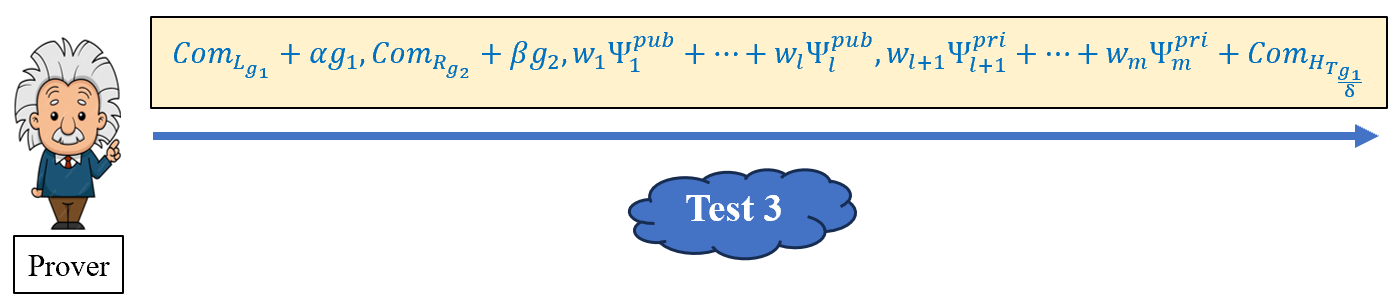

In [ ]:
psi_pubW_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_pub_G1, W_pub)]
psi_pubW_G1 = psi_pubW_G1_terms[0]
for i in range(1, len(psi_pubW_G1_terms)):
    psi_pubW_G1 = add(psi_pubW_G1, psi_pubW_G1_terms[i])
print(f"[psi_pub/γ*w]G1 = {normalize(psi_pubW_G1)}")

psi_priW_G1_terms = [multiply(point, int(scaler)) for point, scaler in zip(psi_pri_G1, W_pri)]
psi_priW_G1 = psi_priW_G1_terms[0]
for i in range(1, len(psi_priW_G1_terms)):
    psi_priW_G1 = add(psi_priW_G1, psi_priW_G1_terms[i])
print(f"[psi_pri/δ*w]G1 = {normalize(psi_priW_G1)}")


Com_H_Tdelta_G1 = compute_commit(Hx, SRS_Ttau_div_delta_G1)
print(f"\n[τT(τ)/δ]G1 = {normalize(Com_H_Tdelta_G1)}")

[psi_pub/γ*w]G1 = (5072867516514994186983365415884963421838989321002869913139206797473937546518, 6008341703728854078836652315192424951575084843791700653336304603085042797192)
[psi_pri/δ*w]G1 = (18213821932038117186276008132738967958924339913809497137035736656708904729707, 7951315937373852497555326788704127677887245578966072178769786569980178781164)

[τT(τ)/δ]G1 = (14876947442848125776556370547246474839327876379113167614153990219429882701496, 1084822493068379491107803529890415295855773462917271514268679231417848105190)


# **Test 3 -Proof Verification by Verifier**

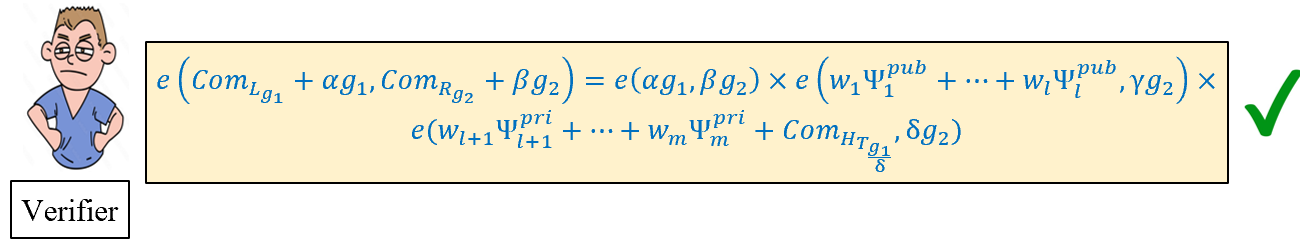

In [ ]:
print("\nProof verification by the verifier:")
print("-"*10)

print(f"pairing(Com_Rbeta_G2,Com_Lalpha_G1) = {pairing(Com_Rbeta_G2,Com_Lalpha_G1)}")
print(f"\npairing(betaG2, alphaG1) = {pairing(betaG2, alphaG1)}")
print(f"pairing(gammaG2, psi_pubW_G1) = {pairing(gammaG2, psi_pubW_G1)}")
print(f"pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1)) = {pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))}")
print(f"pairing(betaG2, alphaG1) * pairing(G2, Com_sum_psi_H_TG1) = {pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))}")

assert pairing(Com_Rbeta_G2,Com_Lalpha_G1) == pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2,add(psi_priW_G1, Com_H_Tdelta_G1))
print("\nPairing check passed!")


Proof verification by the verifier:
----------
pairing(Com_Rbeta_G2,Com_Lalpha_G1) = (18315320689072325987318339888686928926441082924835991541797929305789972708511, 561735336946250655241320754693905052090171931275706394757282629272334035561, 2819579540518582154272583612630673578532241960548125342990723245962393408028, 2450270091158035240806490146116205641702304438430768873404257228289211806875, 8964815260025788331687177081606778988951731817758516356792078048327610303278, 13961744504695830217965810288769940327868983596768014116365339942793057408422, 9470708380232385341823467405856530673994539734709634204080349610241613983628, 9957174780837583358956742704006082847457622905482382506439309322934856236724, 11717073097485800213879760857393898747402838011302455220929810970078851993073, 2559690243784152603210391351796569761569785541724961783192939677986218691944, 15080244493518759585967219176070439710786160305064088969126700528314164895952, 1619751403299499069861880822459607081570692866462890

# **Test 4 - Checking**

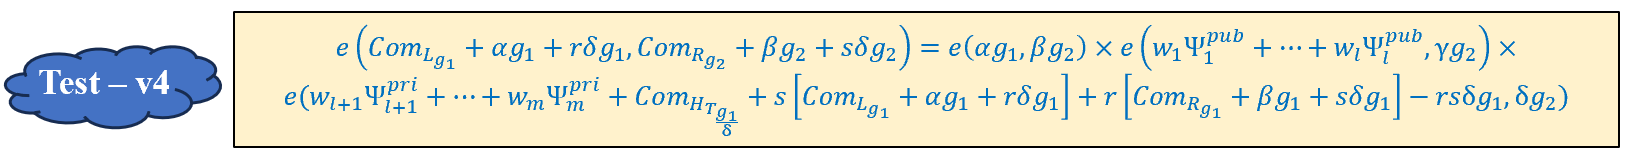

# **Test 4 - Updating SSR values by trusted authority**

In [ ]:
print("Additional Trusted setup:")
print("-"*10)

betaG1 = multiply(G1, int(beta))
deltaG1 = multiply(G1, int(delta))

print(f"[γ]G1 = {normalize(betaG1)}")
print(f"[beta]G1 = {normalize(deltaG1)}")


Additional Trusted setup:
----------
[γ]G1 = (3353031288059533942658390886683067124040920775575537747144343083137631628272, 19321533766552368860946552437480515441416830039777911637913418824951667761761)
[beta]G1 = (10744596414106452074759370245733544594153395043370666422502510773307029471145, 848677436511517736191562425154572367705380862894644942948681172815252343932)


# **Test 4 - Choosing random values r and s by Prover**

In [ ]:
print("Prover picks random r, s")
r = FP(12)
s = FP(13)

print(f"r = {r}")
print(f"s = {s}")

Prover picks random r, s
r = 12
s = 13


# **Test 4 -Proof Generation by Prover**

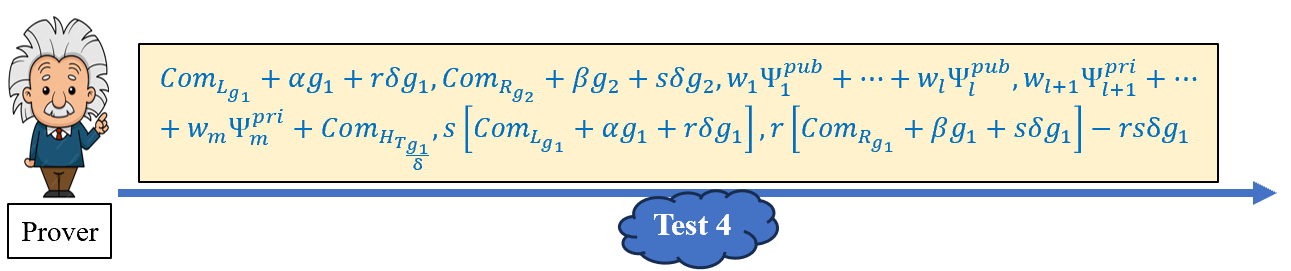

In [ ]:
r_deltaG1 = multiply(deltaG1, int(r))
s_deltaG1 = multiply(deltaG1, int(s))
s_deltaG2 = multiply(deltaG2, int(s))

Com_Lalpha_r_delta_G1 = add(Com_Lalpha_G1, r_deltaG1)
Com_Rbeta_s_delta_G2 = add(Com_Rbeta_G2, s_deltaG2)
print(f"Com_Lalpha_r_delta_G1 = {normalize(Com_Lalpha_r_delta_G1)}")
print(f"Com_Rbeta_s_delta_G2 = {normalize(Com_Lalpha_r_delta_G1)}")

Com_R_G1 = compute_commit(Rx, SRS_G1)
Com_Rbeta_G1 = add(Com_R_G1, betaG1)
Com_Rbeta_s_delta_G1 = add(Com_Rbeta_G1, s_deltaG1)
print(f"Com_Rbeta_s_delta_G1 = {normalize(Com_Rbeta_s_delta_G1)}")

sCom_Lalpha_r_delta_G1 = multiply(Com_Lalpha_r_delta_G1, int(s))
rCom_Rbeta_s_delta_G1 = multiply(Com_Rbeta_s_delta_G1, int(r))
rs_deltaG1 = multiply(deltaG1, int(-r*s))

Com_OHT_G1 = add(psi_priW_G1, Com_H_Tdelta_G1)      #replace Com_H_TG1 by Com_H_Tdelta_G1?
Com_OHT_G1 = add(Com_OHT_G1, sCom_Lalpha_r_delta_G1)
Com_OHT_G1 = add(Com_OHT_G1, rCom_Rbeta_s_delta_G1)
Com_OHT_G1 = add(Com_OHT_G1, rs_deltaG1)

print(f"[A]G1 = {normalize(Com_Lalpha_r_delta_G1)}")
print(f"[B]G2 = {normalize(Com_Rbeta_s_delta_G2)}")
print(f"[C]G1 = {normalize(Com_OHT_G1)}")

print(f"\npairing(Com_Rbeta_s_delta_G2, Com_Lalpha_r_delta_G1) = {pairing(betaG2, alphaG1)}")

Com_Lalpha_r_delta_G1 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
Com_Rbeta_s_delta_G2 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
Com_Rbeta_s_delta_G1 = (17207426683554703593600266110302490039900907866253807106068481151354259979104, 17349420393533926206516910422065028528811183641814064493341547405249552063661)
[A]G1 = (15449831961101541088665067435933884915761366157148486820250069318704068365426, 21488335903123485286445109704897365524769521813989335567410993512517313471430)
[B]G2 = ((13058368473570105012081778605725090762847780389979685315702591676113597548960, 15656371131523471772160755270648713299054878279902664963132188382406698635743), (5078104089308616981607286442358867222649182843626788772815662212280945184541, 88002231028961891181425187934513621574

# **Test 4 -Proof Verification by Verifier**

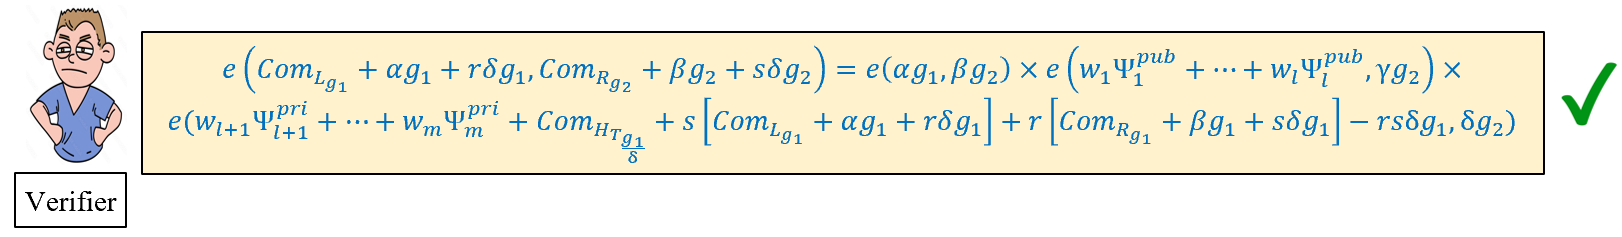

In [ ]:
assert pairing(Com_Rbeta_s_delta_G2, Com_Lalpha_r_delta_G1) == pairing(betaG2, alphaG1) * pairing(gammaG2, psi_pubW_G1) * pairing(deltaG2, Com_OHT_G1)
print("Pairing check passed!")

Pairing check passed!
